In [67]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/manuel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/manuel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Data Science Process

> CRISP-DM CRoss Industry Standard Process for Data Mining

![alt](../assets/Screenshot%202026-06-25%20at%2012.20.14.png)

# Step 1: Business Understanding

# Step 2: Data Understanding

Python-Setup mit UV und den notwendigen Abhängigkeiten eingerichtet.

> pyproject.toml als Dokumentation für die genutzten Pakete

```toml
[project]
name = "dhbw-neuekonzepte-portfolio"
version = "0.1.0"
description = "Add your description here"
readme = "README.md"
requires-python = ">=3.12"
dependencies = [
    "ipykernel>=7.2.0",
    "polars>=1.40.1",
    "pandas>=2.0.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.13.0",
    "pyarrow>=14.0.0",
    "scikit-learn>=1.9.0",
    "nltk>=3.9.4",
]
```

### Datensatz

https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text


## 2.1. Business Understanding

## 2.2. SMART-Ziele

### SMART Ziele (TODO: Olaf)

**Forschungsfrage:** Lassen sich die in kurzen Tweets ausgedrückten Emotionen mit klassischen Machine-Learning-Verfahren zuverlässig automatisch klassifizieren? Welches Modell liefert die beste Vorhersagequalität?

| | Begriff | Bedeutung |
|---|---|---|
| **S** | `⁠Spezifisch⁠` | Emotionen werden durch ML Verfahren klassifiziert. Das für die Klassifizierung am besten geeignete Modell wird hierzu gesucht. |
| **M** | `⁠Messbar` | Das beste Modell erzielt den höchsten F1-Score (macro). |
| **A** | `⁠Attraktiv ` | Durch die fachlich korrekte Anwendung der in der VL vermittelten Methoden wird das Verständniss von Data Science Methoden geschuhlt und verstanden.|
| **R** | `⁠Realistisch` | Der Datensatz sowie die ML-Verfahren sind in der VL-Unterlagen aufgelistet und erläutert. |
| **T** | ⁠`Terminiert`⁠ | Das Notebook wird bis zum 02.07.26 fertigestellt |

**Ziel:** ⁠Den gewählten Datensatz analysieren und nutzbar aufbereiten um die Modellvorhersagen zu ermöglichen.

## 3.1 Data Understanding

### Datensatz einlesen

In [68]:
df = pd.read_csv('../data/csv/tweet_emotion_dataset.csv')   # Datensatz in CSV Format einlesen
df = df.drop(columns=['tweet_id'])                          # Spalte 'tweet_id' entfernen
df.columns = ['emotion', 'content']                         # Spalten umbenennen

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  40000 non-null  str  
 1   content  40000 non-null  str  
dtypes: str(2)
memory usage: 3.7 MB


In [69]:
df

,emotion,content
0,empty,@tiffanylue i know i was listenin to bad habi...
1,sadness,Layin n bed with a headache ughhhh...waitin o...
2,sadness,Funeral ceremony...gloomy friday...
3,enthusiasm,wants to hang out with friends SOON!
4,neutral,@dannycastillo We want to trade with someone w...
...,...,...
39995,neutral,@JohnLloydTaylor
39996,love,Happy Mothers Day All my love
39997,love,Happy Mother's Day to all the mommies out ther...
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...


Der gewählte Datensatz enthält 40.000 Zeilen sowie 3 Spalten. Spalte 1 (tweet_id) wird nicht benötigt und wurde daher entfernt. Spalte 2 enhält die Emotionsklasse zu der in Spalte 3 enthaltenten Kurznachricht (content).

*Ist der Datensatz intuitiv veständlich?* TODO: Manuel

In [70]:
df.describe()

,emotion,content
count,40000,40000
unique,13,39827
top,neutral,I just received a mothers day card from my lov...
freq,8638,14


Beschreibung von df.describe()

+ 163 Dopplungen in Content
+ Visualisierung der Zielvariablen

### Visualisierung der Zielvariablen

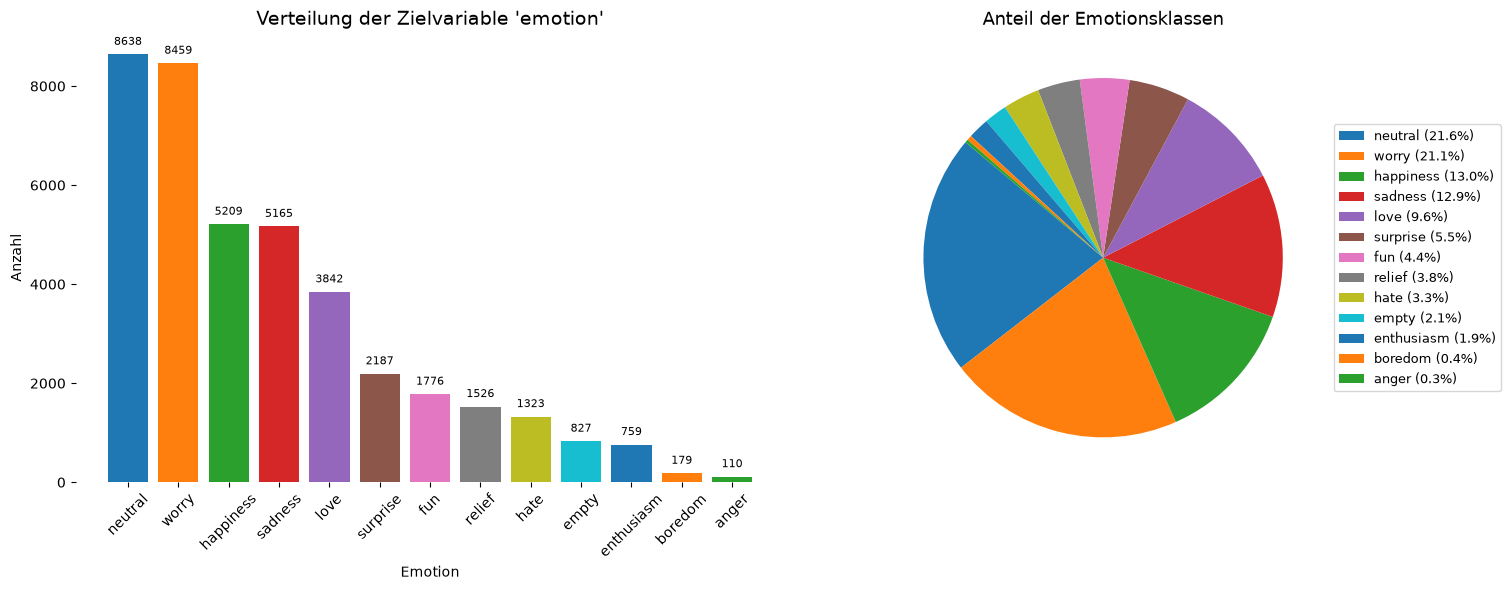

In [71]:
values = df["emotion"].value_counts()
labels = values.index
colors = plt.cm.tab10.colors

pct_labels = [f"{l} ({v/values.sum()*100:.1f}%)" for l, v in zip(labels, values)]

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(16, 6))

bars = ax_bar.bar(labels, values, color=colors[:len(labels)])
ax_bar.set_title("Verteilung der Zielvariable 'emotion'", fontsize=14)
ax_bar.set_xlabel("Emotion")
ax_bar.set_ylabel("Anzahl")
ax_bar.tick_params(axis="x", rotation=45)
ax_bar.spines[:].set_visible(False)
_ = ax_bar.bar_label(bars, padding=5, fontsize=8)

wedges, _ = ax_pie.pie(values, colors=colors[:len(labels)], startangle=140)
ax_pie.set_title("Anteil der Emotionsklassen", fontsize=13)
ax_pie.legend(wedges, pct_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)

plt.tight_layout()
plt.show()


- **Klassenungleichgewicht**: `neutral` (21,6 %) und `worry` (21,1 %) dominieren; `anger` hat nur 110 Einträge (0,3 %).
- *Die **Textlänge** variiert kaum zwischen den Emotionsklassen und ist daher kein Merkmal der Emotion.*
- Für das spätere Modell muss dieses Ungleichgewicht berücksichtigt

# Step 3: Data Preperation

## 3.4. Regex

| Schritt | Regex-Pattern | Beschreibung |
|---------|---------------|--------------|
| Kleinschreibung | `.lower()` | Vereinheitlichung Groß-/Kleinschreibung |
| URLs entfernen | `https?://\S+\|www\.\S+` | HTTP/HTTPS-Links und www-Adressen |
| Mentions entfernen | `@\w+` | Twitter-Nutzernamen wie `@user` |
| Hashtag-Symbol entfernen | `#` | Nur das `#`-Zeichen, das Wort bleibt erhalten |
| Sonderzeichen entfernen | `[^\w\s]` | Punkte, Kommas, Ausrufezeichen etc. |
| Zahlen entfernen | `\d+` | Reine Ziffernfolgen |
| Leerzeichen normalisieren | `\s+` → `' '` | Mehrfache Leerzeichen auf eines reduzieren |

Normalisierung, Skalierung und Standardisierung ist für unseren Datensatz nicht relevant, da es sich um textuelle Daten handelt, welche im folgenden sowieso durch Tokenisierung, Vektorisierung etc. weiterverarbeitet werden müssen. Eine verzeitige Normalisierung ist daher nicht notwendig. Normalisierung im Sinne von Lemmatisierung könnte angewendet werden.

In [72]:
tokens = df.content.str.lower()                                         # Text in Kleinbuchstaben umwandeln
tokens = tokens.str.replace(r'https?://\S+|www\.\S+', '', regex=True)   # Hyperlinks entfernen
tokens = tokens.str.replace(r'@\w+', '', regex=True)                    # Nutzererwähnungen entfernen
tokens = tokens.str.replace(r'#', '', regex=True)                       # Nur das Hashtag-Symbol entfernen
tokens = tokens.str.replace(r'[^\w\s]', '', regex=True)                 # Sonderzeichen entfernen
tokens = tokens.str.replace(r'\d+', '', regex=True)                     # Ziffern/Zahlen entfernen
tokens = tokens.str.replace(r'\s+', ' ', regex=True).str.strip()        # Doppelte Leerzeichen entfernen
df["tokens"] = tokens

## 4.1. Datenqualität

### Fehlende Daten/Werte

In [73]:
df.describe()

,emotion,content,tokens
count,40000,40000,40000
unique,13,39827,38998
top,neutral,I just received a mothers day card from my lov...,
freq,8638,14,99


In [74]:
df.isna().sum()

emotion    0
content    0
tokens     0
dtype: int64

In [75]:
df.isnull().sum()

emotion    0
content    0
tokens     0
dtype: int64

Keine fehlende oder null Werte, die entfernt werden müssten...

In [76]:
df[df.tokens == ""]

,emotion,content,tokens
340,empty,0,
659,neutral,@Joshuah_Pearson,
664,neutral,@emlevins,
2621,surprise,@swpave ?????????????,
3181,neutral,@Clumsyflic,
...,...,...,...
38650,neutral,@Britt_Uh_Knee,
39206,neutral,@hmigroupllc,
39415,neutral,0,
39518,neutral,@Remy_Foster,


ABER: 99 Nachrichten sind durch den Regex filter leer geworden, und werden im Folgenden entfernt:

In [77]:
df = df[df.tokens != ""]        # Zeilen mit leeren Tokens entfernen

### Duplikate

In [78]:
df[df.content.duplicated(keep=False)]

,emotion,content,tokens
51,worry,why am i so tired?,why am i so tired
147,relief,I'm at work,im at work
324,sadness,I feel so deflated. No more doggy.,i feel so deflated no more doggy
366,worry,I feel so deflated. No more doggy.,i feel so deflated no more doggy
454,worry,Somebody please save the polar bears!,somebody please save the polar bears
...,...,...,...
39859,love,Happy Mothers Day,happy mothers day
39898,love,happy mothers day!,happy mothers day
39913,happiness,happy mother's day!,happy mothers day
39915,love,happy mother's day everyone,happy mothers day everyone


262 Nachrichten bzw. deren Tokenfolge sind Duplikate, welche im Folgenden entfernt werden:

In [79]:
df = df.drop_duplicates(subset="content")    # Entfernen von Duplikaten (nach dem Cleaning)

In [80]:
df.info()
df.tail()

<class 'pandas.DataFrame'>
Index: 39733 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  39733 non-null  str  
 1   content  39733 non-null  str  
 2   tokens   39733 non-null  str  
dtypes: str(3)
memory usage: 6.6 MB


,emotion,content,tokens
39994,happiness,Succesfully following Tayla!!,succesfully following tayla
39996,love,Happy Mothers Day All my love,happy mothers day all my love
39997,love,Happy Mother's Day to all the mommies out ther...,happy mothers day to all the mommies out there...
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,wassup beautiful follow me peep out my new hit...
39999,love,@mopedronin bullet train from tokyo the gf ...,bullet train from tokyo the gf and i have been...


### Warum nur die 5 häufigsten Emotionen?

Der Datensatz enthält 13 Emotionsklassen, die sehr ungleich verteilt sind. Die fünf häufigsten Klassen (neutral, worry, happiness, sadness, love) machen zusammen bereits rund 76 % aller Tweets aus (30.464 von 38.998), während die übrigen acht Klassen nur sehr selten vorkommen: `anger`⁠ z.B. mit nur 110 Einträgen (0,3 %).

So wenige Beispiele reichen nicht, damit ein Modell diese seltenen Emotionen zuverlässig lernen kann. Das starke Klassenungleichgewicht würde die Vorhersagequalität verschlechtern und die Ergebnisse verzerren. Durch die Fokussierung auf die **Top-5-Klassen** erhalten wir ein ausgewogeneres und besser lernbares Klassifikationsproblem, ohne den Großteil der Daten zu verlieren.

**Die Top-5-Klassen:**

1. `Neutral`
2. `Worry`
3. `Hapiness`
4. `Sadness`
5. `Love`

In [81]:
keep = ["neutral", "worry", "happiness", "sadness", "love"]     # Filter auf Top5 Emotionsklassen
df_filtered = df[df.emotion.isin(keep)]

print(f"Verbleibende Klassen: {keep}")
print(f"Anteil am Gesamtdatensatz: {len(df) / 40000 * 100:.1f}%")
print(f"Verbleibende Einträge: {len(df_filtered)}")
print(f"Gelöschte Einträge: {len(df) - len(df_filtered)}")

df = df_filtered

Verbleibende Klassen: ['neutral', 'worry', 'happiness', 'sadness', 'love']
Anteil am Gesamtdatensatz: 99.3%
Verbleibende Einträge: 31080
Gelöschte Einträge: 8653


In [82]:
df.info()

<class 'pandas.DataFrame'>
Index: 31080 entries, 1 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  31080 non-null  str  
 1   content  31080 non-null  str  
 2   tokens   31080 non-null  str  
dtypes: str(3)
memory usage: 5.1 MB


## 5.1 Beschreibung des Korpus

Unser Korpus ist die Sammlung von allen Tweets, mit denen wir am Ende arbeiten.

Die Tweets sind alle auf Englisch. Jeder Tweet ist ein eigener Eintrag mit einer zugeordneten Emotion. Nach der Bereinigung und der Beschränkung auf die fünf Klassen besteht unser Korpus aus 30.464 Tweets.

Den Text haben wir danach noch weiter aufgeräumt: Stopwords wie „the", „and" oder „is" raus, Wörter auf ihren Wortstamm gekürzt und Wörter entfernt, die in allen Klassen so oft vorkommen, dass sie nichts über die Emotion aussagen.

Übrig bleibt am Ende ein Wortschatz von rund 23.367 verschiedenen Wörtern. Das ist unsere saubere Textbasis, die wir danach vektorisieren und in die Modelle geben.

## 5.2. Wortfrequenzanalyse

Whitespace Tokenisierung

In [83]:
df["tokens"] = df["tokens"].str.split()     # Whitespace Tokenisierung in Spalte eigene Spalte

In [84]:
df.tail()

,emotion,content,tokens
39994,happiness,Succesfully following Tayla!!,"[succesfully, following, tayla]"
39996,love,Happy Mothers Day All my love,"[happy, mothers, day, all, my, love]"
39997,love,Happy Mother's Day to all the mommies out ther...,"[happy, mothers, day, to, all, the, mommies, o..."
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,"[wassup, beautiful, follow, me, peep, out, my,..."
39999,love,@mopedronin bullet train from tokyo the gf ...,"[bullet, train, from, tokyo, the, gf, and, i, ..."


### Barchart Visualisierung

Anzahl Worte (insgesamt):  383772
Anzahl Worte (unique) - |V|= 28834


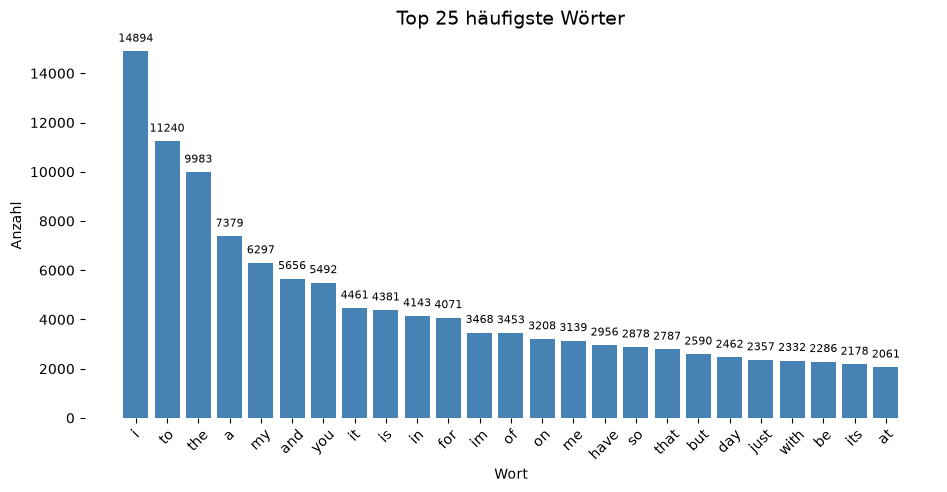

In [85]:
def plot_top_words(top_n=25):
    word_list = np.concatenate(df.tokens.values)

    word_counts = pd.Series(word_list).value_counts()
    word_counts = word_counts.reset_index()
    word_counts.columns = ["word", "count"]

    print("Anzahl Worte (insgesamt): ", len(word_list))
    print("Anzahl Worte (unique) - |V|=", len(word_counts.word))

    top_words = word_counts.head(top_n)

    _, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(top_words["word"], top_words["count"], color="steelblue")
    ax.set_title(f"Top {top_n} häufigste Wörter", fontsize=14)
    ax.set_xlabel("Wort")
    ax.set_ylabel("Anzahl")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[:].set_visible(False)
    _ = ax.bar_label(bars, padding=5, fontsize=8)
    plt.show()

plot_top_words()

Beschreibung der Wortverteilung, Visualisierung

*Ist das hilfreich für unsere Aufgabe?*

### Stopwords entfernen

In [86]:
stop_words = set(stopwords.words("english"))

print("Anzahl von Stopwords: " + str(len(stop_words)))
print("Stopwords: " + str(stop_words))

Anzahl von Stopwords: 198
Stopwords: {'as', 'her', 'just', 'be', 'from', 'about', 'hadn', 'itself', 'than', "he'll", "haven't", 'why', "you're", 'yourself', "they'd", "shouldn't", "you've", "wasn't", 'ma', 'no', 'yourselves', 'couldn', 'nor', "they'll", 'on', "needn't", 'haven', 'shan', 'for', 'these', 'whom', 'into', 'now', 'more', 'myself', "doesn't", 'theirs', 'yours', 'between', "it'll", 'should', 'am', 'aren', 'i', 'both', 'been', 'my', 'ourselves', 'will', "didn't", 'over', 'were', 'through', "wouldn't", 'y', 'ain', 'hasn', 'he', 'where', 'them', "mightn't", 'him', 'she', 'wouldn', 'what', "don't", 've', 'mightn', "i've", "shan't", 'themselves', 'when', 'out', 'his', 'the', "i'd", 'if', 'o', 'up', "i'll", 't', 'can', 'needn', 'you', "he's", 'during', 'any', 'some', 'down', 'so', "isn't", 'are', 'an', 'further', 'such', 'above', 'mustn', 'didn', 'which', 'under', 'at', 'who', 'do', 'off', "hadn't", "we're", 'while', "won't", "it's", 'after', 'this', 'weren', 'before', 'herself', "

In [87]:
df.tokens = df.tokens.apply(lambda tokens: [w for w in tokens if w not in stop_words])  # Stopwords entfernen

In [88]:
def top_words_all(n=30):
    return pd.DataFrame([{
        "emotion": emotion,
        "top_words": pd.Series(
            np.concatenate(df[df["emotion"] == emotion]["tokens"].values)
        ).value_counts().head(n).index.tolist()
    } for emotion in df["emotion"].unique()]).set_index("emotion")

top_words_all()

,top_words
emotion,
sadness,"[im, sad, day, miss, work, go, get, like, cant..."
neutral,"[im, get, day, go, good, like, work, going, do..."
worry,"[im, dont, get, cant, like, go, day, got, good..."
love,"[love, day, happy, mothers, im, good, thanks, ..."
happiness,"[day, good, im, happy, thanks, great, lol, tod..."


In [89]:
# Entfernen von Wörtern die in allen Klassen unter den Top30 Wörtern sind

while common := set.intersection(*[set(w) for w in top_words_all().top_words]):
    df.tokens = df.tokens.apply(lambda t: [w for w in t if w not in common])
    print("Removed:", common)

Removed: {'day', 'u', 'good', 'like', 'im', 'time', 'got', 'go', 'today', 'one', 'get'}
Removed: {'really', 'night', 'lol', 'cant', 'see', 'going', 'amp', 'know', 'well', 'much'}
Removed: {'home', 'new', 'dont', 'oh', 'thats', 'back', 'think'}
Removed: {'ill', 'still', 'work', 'love'}
Removed: {'want', 'tomorrow'}
Removed: {'last', 'tonight'}


Anzahl Worte (insgesamt):  181226
Anzahl Worte (unique) - |V|= 28658


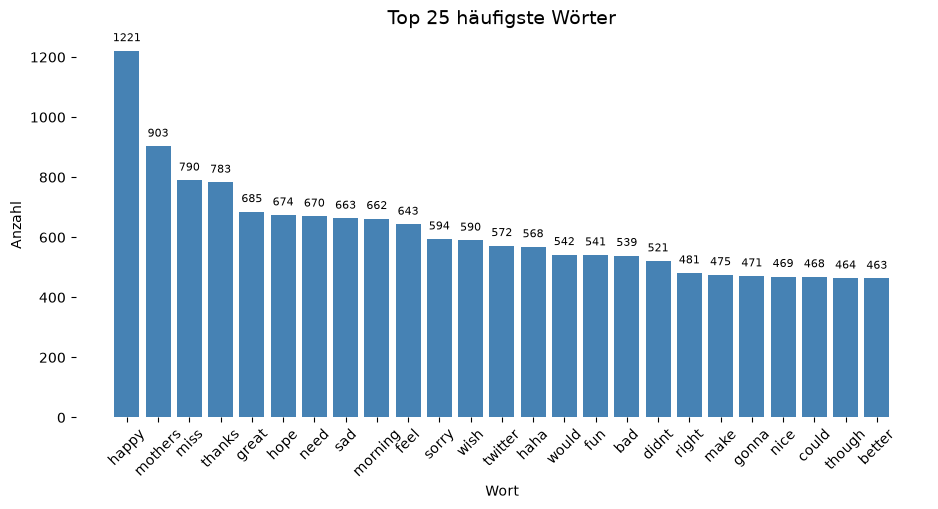

In [90]:
plot_top_words()

### Byte Pair Encoding




Beispiel encoded:  ['bul', 'let', 'train', 'tokyo', 'gf', 'visiting', 'japan', 'since', 'thursday', 'vacationsightseeing', 'gaijin', 'godzilla']
Anzahl BPE-Tokens (insgesamt): 188877
Anzahl einzigartiger BPE-Tokens |V|: 26862


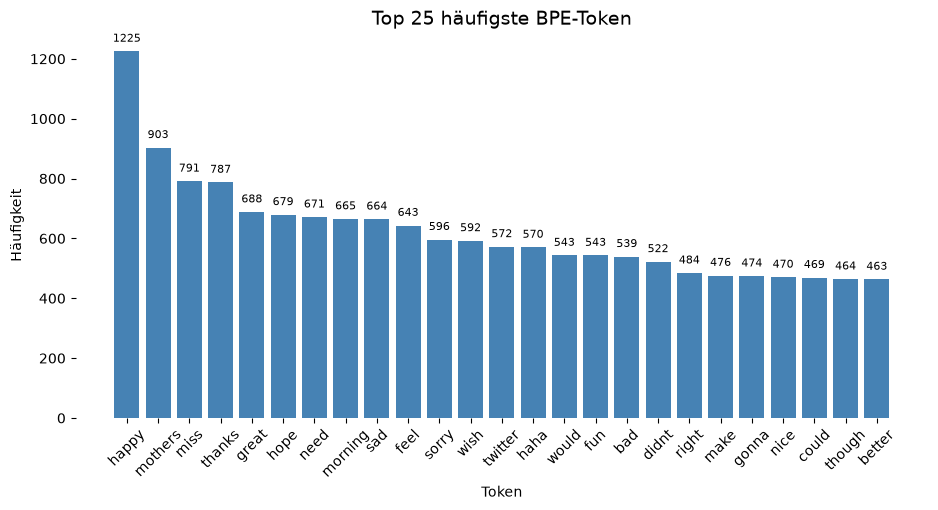

In [91]:
bpe_corpus = df.tokens.apply(" ".join)

tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace() # zunächst Trennung durch Leerzeichen
trainer = BpeTrainer(vocab_size=30000) # k=30000

# Liste mit Texten
tokenizer.train_from_iterator(bpe_corpus) # tokenizer.train_from_iterator(iterator, trainer) - iteriere über die Tweets und verwende BPE als Trainer

# Text tokenisieren und Token zählen
all_tokens = []
for sentence in bpe_corpus: # iteriere durch jede Zeile der Tweets, sentence1 = erste Zeile in df.Tweet
    encoded = tokenizer.encode(sentence) # Elemente des sentence werden Tokenisiert
    all_tokens.extend(encoded.tokens) # .extend() fügt Elemente an das Ende einer Liste an

print("Beispiel encoded: ", encoded.tokens)
print(f"Anzahl BPE-Tokens (insgesamt): {len(all_tokens)}")
print(f"Anzahl einzigartiger BPE-Tokens |V|: {len(set(all_tokens))}")

# Häufigkeiten
top_n = 25
token_series = pd.Series(all_tokens) # umwandeln der Liste als Pandas Series
token_freq = token_series.value_counts()  # zählt Token
top_tokens = token_freq.head(top_n)

_, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(top_tokens.index, top_tokens.values, color="steelblue")
ax.set_title(f"Top {top_n} häufigste BPE-Token", fontsize=14)
ax.set_xlabel("Token")
ax.set_ylabel("Häufigkeit")
ax.tick_params(axis="x", rotation=45)
ax.spines[:].set_visible(False)
_ = ax.bar_label(bars, padding=5, fontsize=8)
plt.show()

Byte Pair Encoding (BPE) ist für uns nicht weiter relevant, da es nicht auf Wort sondern auf Zeicheneben arbeitet. Bei BPE werden werden Wörter in Wortfragmente zerteilt, welches insbesondere für Transformer Modelle wichtig ist. Für einfache Classifier ist dies nicht notwendig oder ggf. sogar kontroproduktiv.

### Lemmatisierung

In [92]:
df["tokens"] = df.tokens.apply(lambda tokens: [PorterStemmer().stem(w) for w in tokens])

Anzahl Worte (insgesamt):  181226
Anzahl Worte (unique) - |V|= 23407


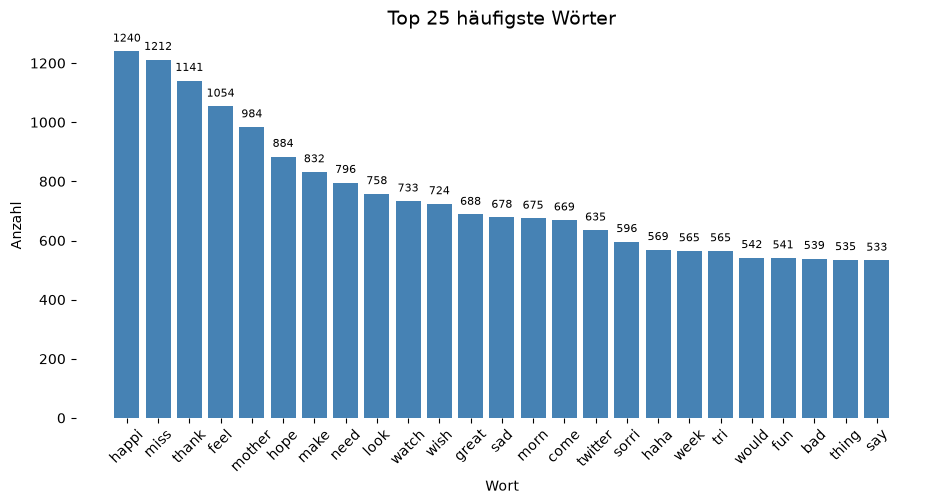

In [93]:
plot_top_words()

---

Nach Datenaufbereitung kann der finale Korpus definiert werden. Die zuvor durch Whitespace Tokenization erzeugte Tokenliste wird für die weitere Verarbeitung wieder in einen String umgewandelt.

In [94]:
corpus = df.tokens.apply(" ".join)

## 5.3. Vektorisierung

In [95]:
X = corpus
y = df.emotion

n_gram = (1, 2)

### Bag-of-Words (`CountVectorizer`)

In [96]:
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(X)

print("Anzahl der Features: " + str(count_vectorizer.get_feature_names_out().shape[0]))
print(X_count)

Anzahl der Features: 23388
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 176039 stored elements and shape (31080, 23388)>
  Coords	Values
  (0, 10957)	1
  (0, 1773)	1
  (0, 8569)	1
  (0, 21188)	1
  (0, 2927)	1
  (1, 7277)	1
  (1, 3239)	1
  (1, 7143)	1
  (2, 20662)	1
  (2, 18569)	1
  (2, 9148)	1
  (2, 20237)	1
  (3, 16718)	1
  (3, 5074)	2
  (3, 15551)	1
  (3, 1691)	1
  (3, 1947)	1
  (3, 7158)	1
  (4, 7158)	1
  (4, 18304)	1
  (4, 20096)	1
  (4, 14026)	1
  (4, 8565)	1
  (4, 11988)	1
  (4, 4580)	1
  :	:
  (31077, 11874)	1
  (31077, 11390)	1
  (31077, 12670)	1
  (31077, 12854)	1
  (31077, 12664)	1
  (31078, 21714)	1
  (31078, 8874)	1
  (31078, 18169)	1
  (31078, 4848)	1
  (31078, 22047)	1
  (31078, 6914)	1
  (31078, 14718)	1
  (31078, 1743)	1
  (31078, 22042)	1
  (31079, 20223)	1
  (31079, 21782)	1
  (31079, 18161)	1
  (31079, 20680)	1
  (31079, 20471)	1
  (31079, 9986)	1
  (31079, 7561)	1
  (31079, 2715)	1
  (31079, 21577)	1
  (31079, 7372)	1
  (31079, 7766)	1


In [102]:
count_vectorizer_ngram = CountVectorizer(ngram_range=n_gram)
X_count_ngram = count_vectorizer_ngram.fit_transform(X)

print("Anzahl der Features: " + str(count_vectorizer_ngram.get_feature_names_out().shape[0]))
print(X_count_ngram)

Anzahl der Features: 148089
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 324985 stored elements and shape (31080, 148089)>
  Coords	Values
  (0, 68586)	1
  (0, 10580)	1
  (0, 55471)	1
  (0, 132844)	1
  (0, 17518)	1
  (0, 68587)	1
  (0, 10669)	1
  (0, 55537)	1
  (0, 132845)	1
  (1, 46497)	1
  (1, 19553)	1
  (1, 45145)	1
  (1, 46499)	1
  (1, 19554)	1
  (2, 129549)	1
  (2, 114954)	1
  (2, 59723)	1
  (2, 127131)	1
  (2, 129557)	1
  (2, 115011)	1
  (2, 59729)	1
  (3, 103519)	1
  (3, 30490)	2
  (3, 98489)	1
  (3, 10006)	1
  :	:
  (31078, 57654)	1
  (31078, 112842)	1
  (31078, 29480)	1
  (31078, 137810)	1
  (31079, 127017)	1
  (31079, 135842)	1
  (31079, 112628)	1
  (31079, 129656)	1
  (31079, 128382)	1
  (31079, 63985)	1
  (31079, 47987)	1
  (31079, 16475)	1
  (31079, 135002)	1
  (31079, 46855)	1
  (31079, 49277)	1
  (31079, 16477)	1
  (31079, 129696)	1
  (31079, 128386)	1
  (31079, 47999)	1
  (31079, 135865)	1
  (31079, 63987)	1
  (31079, 112734)	1
  (31079, 127039)	1
  (3107

### TF-IDF Ansatz (`TfidfVectorizer`)

In [99]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(X)

print("Anzahl der Features: " + str(tfidf_vectorizer.get_feature_names_out().shape[0]))
print(X_tfidf)

Anzahl der Features: 23388
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 176039 stored elements and shape (31080, 23388)>
  Coords	Values
  (0, 10957)	0.5718238456399622
  (0, 1773)	0.30294987513978655
  (0, 8569)	0.3645660853975673
  (0, 21188)	0.5944532139822113
  (0, 2927)	0.30814900368884085
  (1, 7277)	0.5791504699866704
  (1, 3239)	0.7142698835198532
  (1, 7143)	0.3929418107185264
  (2, 20662)	0.5664522835293838
  (2, 18569)	0.3790385874315778
  (2, 9148)	0.584846004672798
  (2, 20237)	0.4397916672021949
  (3, 16718)	0.4931836934167751
  (3, 5074)	0.5057631770659459
  (3, 15551)	0.3711586672661132
  (3, 1691)	0.3680942202315269
  (3, 1947)	0.40444484627834787
  (3, 7158)	0.25327003047383984
  (4, 7158)	0.2554156229105155
  (4, 18304)	0.25681140076110176
  (4, 20096)	0.30375259305139674
  (4, 14026)	0.29286700034293606
  (4, 8565)	0.30613771949158414
  (4, 11988)	0.40017196838037666
  (4, 4580)	0.304272865015064
  :	:
  (31077, 11874)	0.31775524809499167
  (31077, 

In [101]:
tfidf_vectorizer_ngram = TfidfVectorizer(ngram_range=n_gram)
X_tfidf_ngram = tfidf_vectorizer_ngram.fit_transform(X)

print("Anzahl der Features: " + str(tfidf_vectorizer_ngram.get_feature_names_out().shape[0]))
print(X_tfidf_ngram)

Anzahl der Features: 148089
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 324985 stored elements and shape (31080, 148089)>
  Coords	Values
  (0, 68586)	0.3701062124538872
  (0, 10580)	0.19608071909956848
  (0, 55471)	0.23596108151913084
  (0, 132844)	0.384752803132526
  (0, 17518)	0.19944579348396713
  (0, 68587)	0.3701062124538872
  (0, 10669)	0.384752803132526
  (0, 55537)	0.384752803132526
  (0, 132845)	0.384752803132526
  (1, 46497)	0.4074522469230417
  (1, 19553)	0.5025133951049401
  (1, 45145)	0.27644805967429686
  (1, 46499)	0.5025133951049401
  (1, 19554)	0.5025133951049401
  (2, 129549)	0.36630508133801554
  (2, 114954)	0.24511113228157427
  (2, 59723)	0.3781996640159536
  (2, 127131)	0.2843980457145156
  (2, 129557)	0.44038766480968355
  (2, 115011)	0.44038766480968355
  (2, 59729)	0.44038766480968355
  (3, 103519)	0.3050513546350537
  (3, 30490)	0.3128322050139533
  (3, 98489)	0.2295746103235169
  (3, 10006)	0.2276791427085365
  :	:
  (31078, 57654)	0.288376

### Bigrams (TODO: Gemeinsam)

Entscheiden, ob wir Bigrams überhaupt verwenden wollen!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Top 10 CountVectorizer features by total count
count_sums = np.asarray(X_count.sum(axis=0)).flatten()
count_top10_idx = count_sums.argsort()[::-1][:20]
count_features = count_vectorizer.get_feature_names_out()[count_top10_idx]
count_values = count_sums[count_top10_idx]

# Top 10 TF-IDF features by mean score
tfidf_means = np.asarray(X_tfidf.mean(axis=0)).flatten()
tfidf_top10_idx = tfidf_means.argsort()[::-1][:20]
tfidf_features = tfidf_vectorizer.get_feature_names_out()[tfidf_top10_idx]
tfidf_values = tfidf_means[tfidf_top10_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

bars1 = ax1.barh(count_features[::-1], count_values[::-1], color="steelblue")
ax1.set_title("Top 10 Bigrams – CountVectorizer\n(Gesamthäufigkeit im Trainingsset)", fontsize=12)
ax1.set_xlabel("Summe der Häufigkeiten")
ax1.bar_label(bars1, fmt="{:.0f}", padding=4, fontsize=8)
ax1.spines[:].set_visible(False)

bars2 = ax2.barh(tfidf_features[::-1], tfidf_values[::-1], color="darkorange")
ax2.set_title("Top 10 Bigrams – TF-IDF\n(Mittlerer TF-IDF-Score im Trainingsset)", fontsize=12)
ax2.set_xlabel("Mittlerer TF-IDF-Score")
ax2.bar_label(bars2, fmt="{:.4f}", padding=4, fontsize=8)
ax2.spines[:].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
classes = sorted(y.unique())
count_names = count_vectorizer.get_feature_names_out()
tfidf_names = tfidf_vectorizer.get_feature_names_out()
y_train_arr = y.values

fig, axes = plt.subplots(len(classes), 2, figsize=(16, len(classes) * 3))
fig.suptitle("Top 10 Features pro Klasse", fontsize=14, fontweight="bold", y=1.01)

for row, cls in enumerate(classes):
    mask = y_train_arr == cls

    cls_count = np.asarray(X_count[mask].sum(axis=0)).flatten()
    top_idx = cls_count.argsort()[::-1][:10]
    ax = axes[row, 0]
    bars = ax.barh(count_names[top_idx][::-1], cls_count[top_idx][::-1], color="steelblue")
    ax.set_title(f"{cls} – CountVectorizer", fontsize=10)
    ax.bar_label(bars, fmt="{:.0f}", padding=3, fontsize=7)
    ax.spines[:].set_visible(False)
    ax.tick_params(labelsize=8)

    cls_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top_idx = cls_tfidf.argsort()[::-1][:10]
    ax = axes[row, 1]
    bars = ax.barh(tfidf_names[top_idx][::-1], cls_tfidf[top_idx][::-1], color="darkorange")
    ax.set_title(f"{cls} – TF-IDF", fontsize=10)
    ax.bar_label(bars, fmt="{:.4f}", padding=3, fontsize=7)
    ax.spines[:].set_visible(False)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Mean TF-IDF score per class for every term
class_scores = np.vstack([
    np.asarray(X_tfidf[y_train_arr == cls].mean(axis=0)).flatten()
    for cls in classes
])  # shape: (n_classes, n_features)

# Distinctiveness: score in this class minus max score in any other class
unique_words = {}
for i, cls in enumerate(classes):
    other_max = np.delete(class_scores, i, axis=0).max(axis=0)
    distinctiveness = class_scores[i] - other_max
    top_idx = distinctiveness.argsort()[::-1][:10]
    unique_words[cls] = tfidf_names[top_idx].tolist()

pd.DataFrame(unique_words)

# Step 4: Modellierung

## 6.0 Machine Learning

TODO:

+ Inputvariablen:
+ Outputvariablen: 
+ Prediction vs. Inference: Prediction
+ Classification vs. Regression: Classification

## 7.1 Training und Test von Modellen

In [114]:
X_count_train, X_count_test, y_count_train, y_count_test = train_test_split(X_count, y, test_size=0.3, stratify=y, random_state=42)
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(X_tfidf, y, test_size=0.3, stratify=y, random_state=42)
X_count_ngram_train, X_count_ngram_test, y_count_ngram_train, y_count_ngram_test = train_test_split(X_count_ngram, y, test_size=0.3, stratify=y, random_state=42)
X_tfidf_ngram_train, X_tfidf_ngram_test, y_tfidf_ngram_train, y_tfidf_ngram_test = train_test_split(X_tfidf_ngram, y, test_size=0.3, stratify=y, random_state=42)

In [ ]:
results = {}

### K Nearest Neighbor

In [127]:
# CV + KNN

model_count_knn = KNeighborsClassifier(n_neighbors=21).fit(X_count_train, y_count_train)
print("=== CountVectorizer + KNN ===")
print(classification_report(y_count_test, model_count_knn.predict(X_count_test), zero_division=0))
results["CV + KNN"] = f1_score(y_count_test, model_count_knn.predict(X_count_test), average="macro")

=== CountVectorizer + KNN ===
              precision    recall  f1-score   support

   happiness       0.43      0.09      0.15      1555
        love       0.51      0.14      0.21      1135
     neutral       0.31      0.92      0.46      2559
     sadness       0.47      0.14      0.22      1545
       worry       0.44      0.11      0.17      2530

    accuracy                           0.34      9324
   macro avg       0.43      0.28      0.24      9324
weighted avg       0.42      0.34      0.26      9324



In [128]:
# TF-IDF + KNN

model_tfidf_knn = KNeighborsClassifier(n_neighbors=21).fit(X_tfidf_train, y_tfidf_train)
print("=== TF-IDF + KNN ===")
print(classification_report(y_tfidf_test, model_tfidf_knn.predict(X_tfidf_test), zero_division=0))
results["TF-IDF + KNN"] = f1_score(y_tfidf_test, model_tfidf_knn.predict(X_tfidf_test), average="macro")

=== TF-IDF + KNN ===
              precision    recall  f1-score   support

   happiness       0.47      0.04      0.07      1555
        love       0.49      0.09      0.15      1135
     neutral       0.28      0.95      0.43      2559
     sadness       0.43      0.02      0.05      1545
       worry       0.34      0.02      0.05      2530

    accuracy                           0.29      9324
   macro avg       0.40      0.22      0.15      9324
weighted avg       0.38      0.29      0.17      9324



In [129]:
# CV + Ngram + KNN

model_count_ngram_knn = KNeighborsClassifier(n_neighbors=21).fit(X_count_ngram_train, y_count_ngram_train)
print("=== CountVectorizer + Ngram + KNN ===")
print(classification_report(y_count_ngram_test, model_count_ngram_knn.predict(X_count_ngram_test), zero_division=0))
results["CV + Ngram + KNN"] = f1_score(y_count_ngram_test, model_count_ngram_knn.predict(X_count_ngram_test), average="macro")

=== CountVectorizer + Ngram + KNN ===
              precision    recall  f1-score   support

   happiness       0.43      0.07      0.12      1555
        love       0.50      0.12      0.19      1135
     neutral       0.30      0.93      0.46      2559
     sadness       0.45      0.12      0.18      1545
       worry       0.46      0.10      0.17      2530

    accuracy                           0.33      9324
   macro avg       0.43      0.27      0.22      9324
weighted avg       0.41      0.33      0.24      9324



In [131]:
# TF-IDF + Ngram + KNN

model_tfidf_ngram_knn = KNeighborsClassifier(n_neighbors=21).fit(X_tfidf_ngram_train, y_tfidf_ngram_train)
print("=== TF-IDF + Ngram + KNN ===")
print(classification_report(y_tfidf_ngram_test, model_tfidf_ngram_knn.predict(X_tfidf_ngram_test), zero_division=0))
results["TF-IDF + Ngram + KNN"] = f1_score(y_tfidf_ngram_test, model_tfidf_ngram_knn.predict(X_tfidf_ngram_test), average="macro")

=== TF-IDF + Ngram + KNN ===
              precision    recall  f1-score   support

   happiness       0.42      0.01      0.03      1555
        love       0.53      0.04      0.07      1135
     neutral       0.28      0.98      0.43      2559
     sadness       0.44      0.01      0.01      1545
       worry       0.35      0.01      0.03      2530

    accuracy                           0.28      9324
   macro avg       0.40      0.21      0.11      9324
weighted avg       0.38      0.28      0.14      9324



### Random forest

In [132]:
# CV + RF

model_count_rf = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=42, n_jobs=-1).fit(X_count_train, y_count_train)
print("=== CountVectorizer + RandomForest ===")
print(classification_report(y_count_test, model_count_rf.predict(X_count_test), zero_division=0))
results["CV + RF"] = f1_score(y_count_test, model_count_rf.predict(X_count_test), average="macro")

=== CountVectorizer + RandomForest ===
              precision    recall  f1-score   support

   happiness       0.36      0.36      0.36      1555
        love       0.31      0.36      0.33      1135
     neutral       0.40      0.48      0.44      2559
     sadness       0.33      0.33      0.33      1545
       worry       0.39      0.28      0.33      2530

    accuracy                           0.37      9324
   macro avg       0.36      0.36      0.36      9324
weighted avg       0.37      0.37      0.36      9324



In [133]:
# TF-IDF + RF

model_tfidf_rf = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=42, n_jobs=-1).fit(X_tfidf_train, y_tfidf_train)
print("=== TF-IDF + RandomForest ===")
print(classification_report(y_tfidf_test, model_tfidf_rf.predict(X_tfidf_test), zero_division=0))
results["TF-IDF + RF"] = f1_score(y_tfidf_test, model_tfidf_rf.predict(X_tfidf_test), average="macro")

=== TF-IDF + RandomForest ===
              precision    recall  f1-score   support

   happiness       0.38      0.39      0.39      1555
        love       0.37      0.34      0.36      1135
     neutral       0.41      0.53      0.46      2559
     sadness       0.36      0.32      0.34      1545
       worry       0.41      0.32      0.36      2530

    accuracy                           0.39      9324
   macro avg       0.39      0.38      0.38      9324
weighted avg       0.39      0.39      0.39      9324



In [134]:
# CV + Ngram + RF

model_count_ngram_rf = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=42, n_jobs=-1).fit(X_count_ngram_train, y_count_ngram_train)
print("=== CountVectorizer + Ngram + RandomForest ===")
print(classification_report(y_count_ngram_test, model_count_ngram_rf.predict(X_count_ngram_test), zero_division=0))
results["CV + Ngram + RF"] = f1_score(y_count_ngram_test, model_count_ngram_rf.predict(X_count_ngram_test), average="macro")

=== CountVectorizer + Ngram + RandomForest ===
              precision    recall  f1-score   support

   happiness       0.36      0.34      0.35      1555
        love       0.31      0.33      0.32      1135
     neutral       0.40      0.54      0.46      2559
     sadness       0.34      0.33      0.33      1545
       worry       0.40      0.27      0.32      2530

    accuracy                           0.37      9324
   macro avg       0.36      0.36      0.36      9324
weighted avg       0.37      0.37      0.37      9324



In [135]:
# TF-IDF + Ngram + RF

model_tfidf_ngram_rf = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=42, n_jobs=-1).fit(X_tfidf_ngram_train, y_tfidf_ngram_train)
print("=== TF-IDF + Ngram + RandomForest ===")
print(classification_report(y_tfidf_ngram_test, model_tfidf_ngram_rf.predict(X_tfidf_ngram_test), zero_division=0))
results["TF-IDF + Ngram + RF"] = f1_score(y_tfidf_ngram_test, model_tfidf_ngram_rf.predict(X_tfidf_ngram_test), average="macro")

=== TF-IDF + Ngram + RandomForest ===
              precision    recall  f1-score   support

   happiness       0.39      0.38      0.38      1555
        love       0.37      0.31      0.33      1135
     neutral       0.39      0.60      0.47      2559
     sadness       0.38      0.31      0.34      1545
       worry       0.43      0.30      0.35      2530

    accuracy                           0.40      9324
   macro avg       0.39      0.38      0.38      9324
weighted avg       0.40      0.40      0.39      9324



### Decision Tree

In [136]:
# CV + DT

model_count_dt = DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=3, random_state=42).fit(X_count_train, y_count_train)
print("=== CountVectorizer + DecisionTree ===")
print(classification_report(y_count_test, model_count_dt.predict(X_count_test), zero_division=0))
results["CV + DT"] = f1_score(y_count_test, model_count_dt.predict(X_count_test), average="macro")

=== CountVectorizer + DecisionTree ===
              precision    recall  f1-score   support

   happiness       0.34      0.41      0.37      1555
        love       0.27      0.40      0.32      1135
     neutral       0.43      0.34      0.38      2559
     sadness       0.31      0.41      0.36      1545
       worry       0.40      0.27      0.32      2530

    accuracy                           0.35      9324
   macro avg       0.35      0.37      0.35      9324
weighted avg       0.37      0.35      0.35      9324



In [137]:
# TF-IDF + DT

model_tfidf_dt = DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=3, random_state=42).fit(X_tfidf_train, y_tfidf_train)
print("=== TF-IDF + DecisionTree ===")
print(classification_report(y_tfidf_test, model_tfidf_dt.predict(X_tfidf_test), zero_division=0))
results["TF-IDF + DT"] = f1_score(y_tfidf_test, model_tfidf_dt.predict(X_tfidf_test), average="macro")

=== TF-IDF + DecisionTree ===
              precision    recall  f1-score   support

   happiness       0.31      0.31      0.31      1555
        love       0.22      0.35      0.27      1135
     neutral       0.40      0.34      0.37      2559
     sadness       0.29      0.34      0.31      1545
       worry       0.38      0.29      0.33      2530

    accuracy                           0.32      9324
   macro avg       0.32      0.33      0.32      9324
weighted avg       0.34      0.32      0.33      9324



In [138]:
# CV + Ngram + DT

model_count_ngram_dt = DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=3, random_state=42).fit(X_count_ngram_train, y_count_ngram_train)
print("=== CountVectorizer + Ngram + DecisionTree ===")
print(classification_report(y_count_ngram_test, model_count_ngram_dt.predict(X_count_ngram_test), zero_division=0))
results["CV + Ngram + DT"] = f1_score(y_count_ngram_test, model_count_ngram_dt.predict(X_count_ngram_test), average="macro")

=== CountVectorizer + Ngram + DecisionTree ===
              precision    recall  f1-score   support

   happiness       0.34      0.41      0.37      1555
        love       0.28      0.40      0.33      1135
     neutral       0.45      0.38      0.41      2559
     sadness       0.32      0.42      0.36      1545
       worry       0.40      0.26      0.32      2530

    accuracy                           0.36      9324
   macro avg       0.36      0.37      0.36      9324
weighted avg       0.38      0.36      0.36      9324



In [139]:
# TF-IDF + Ngram + DT

model_tfidf_ngram_dt = DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=3, random_state=42).fit(X_tfidf_ngram_train, y_tfidf_ngram_train)
print("=== TF-IDF + Ngram + DecisionTree ===")
print(classification_report(y_tfidf_ngram_test, model_tfidf_ngram_dt.predict(X_tfidf_ngram_test), zero_division=0))
results["TF-IDF + Ngram + DT"] = f1_score(y_tfidf_ngram_test, model_tfidf_ngram_dt.predict(X_tfidf_ngram_test), average="macro")

=== TF-IDF + Ngram + DecisionTree ===
              precision    recall  f1-score   support

   happiness       0.29      0.28      0.29      1555
        love       0.23      0.38      0.29      1135
     neutral       0.41      0.35      0.38      2559
     sadness       0.28      0.33      0.30      1545
       worry       0.39      0.31      0.34      2530

    accuracy                           0.33      9324
   macro avg       0.32      0.33      0.32      9324
weighted avg       0.34      0.33      0.33      9324



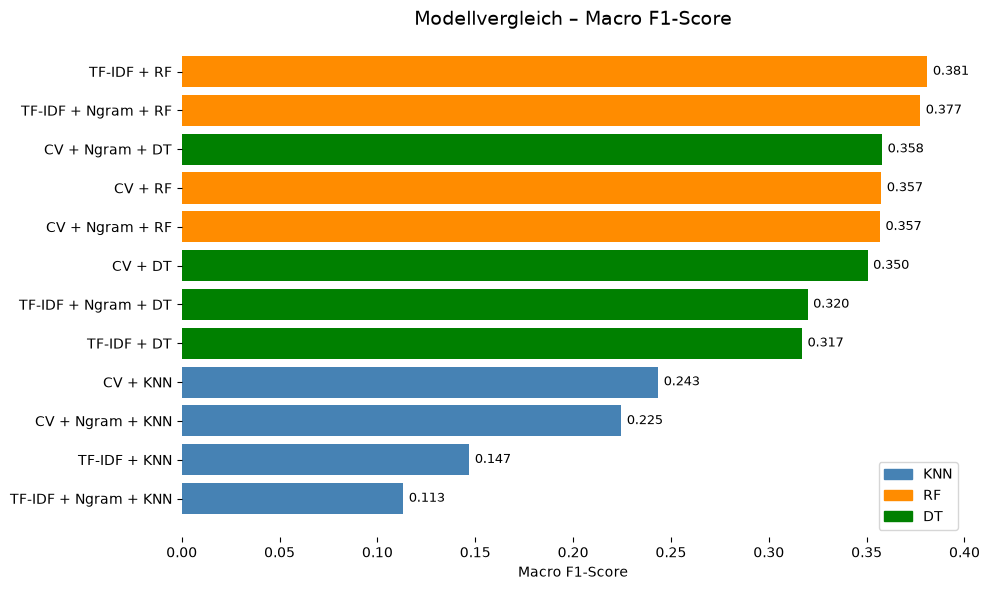

In [140]:
results_df = pd.Series(results).sort_values()
color_map = {"KNN": "steelblue", "RF": "darkorange", "DT": "green"}
colors = [next(c for k, c in color_map.items() if k in name) for name in results_df.index]

_, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(results_df.index, results_df.values, color=colors)
ax.set_title("Modellvergleich – Macro F1-Score", fontsize=14)
ax.set_xlabel("Macro F1-Score")
ax.bar_label(bars, fmt="{:.3f}", padding=4, fontsize=9)
ax.spines[:].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=k) for k, c in color_map.items()], loc="lower right")

plt.tight_layout()
plt.show()

# Step 5: Evaluation